In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

from tencirchem import UCCSD, M
from tencirchem.static.ci_utils import get_ci_strings, get_init_civector

plt.style.use("seaborn-v0_8-whitegrid")

/Users/zacharyhe/cross_chips_sim/.venv_h4_tencirchem/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
# Cl2 linear geometry (angstrom), atoms on z-axis
def make_cl2(d):
    return M(atom=[["Cl", 0, 0, -d / 2], ["Cl", 0, 0, d / 2]], basis="sto-3g", unit="Angstrom")


# Active space for Cl2: 14 electrons in 8 spatial orbitals
active_space = (14, 8)
N_SPATIAL_ORBITALS = active_space[1]
N_QUBITS = 2 * N_SPATIAL_ORBITALS
N_ACTIVE_ELECTRONS = active_space[0]
ETA = N_ACTIVE_ELECTRONS // 2  # occupied spatial orbitals per spin sector (paper eta)

# Bond-length scan grid: 1.0 to 3.0 A
d_grid = np.round(np.arange(1.0, 3.01, 0.2), 2)


def _paper_hf_and_excited_bitstrings(n_qubits, n_elec):
    """Paper qubit layout: alpha sector (low MO index first), then beta sector."""
    eta = n_elec // 2
    half = n_qubits // 2

    hf = []
    for _sector in range(2):
        hf.extend(["1" if local < eta else "0" for local in range(half)])

    exc = hf.copy()
    exc[eta - 1] = "0"
    exc[eta + half - 1] = "0"
    exc[eta] = "1"
    exc[eta + half] = "1"
    return "".join(hf), "".join(exc)


def _paper_to_tencirchem_bitstring(paper_bits, n_qubits, n_elec):
    """Map paper spin-orbital bit order to TenCirChem's internal qubit order."""
    eta = n_elec // 2
    half = n_qubits // 2
    tc_bits = ["0"] * n_qubits

    for sector_start in (0, half):
        for local in range(half):
            if paper_bits[sector_start + local] != "1":
                continue
            if local < eta:
                tc_local = local + (half - eta)
            else:
                tc_local = local - eta
            tc_bits[sector_start + tc_local] = "1"

    return "".join(tc_bits)


def build_multireference_init_civector(ucc, beta):
    """Paper Eq. (6): (|HF> - beta|exc>) / sqrt(1 + beta^2) in TenCirChem CI basis."""
    if beta == 0.0:
        return None

    n_qubits = ucc.n_qubits
    n_elec = ucc.n_elec
    ci_strings = get_ci_strings(n_qubits, n_elec, ucc.hcb)
    hf_ci = get_init_civector(len(ci_strings))

    _, paper_exc = _paper_hf_and_excited_bitstrings(n_qubits, n_elec)
    exc_bits = _paper_to_tencirchem_bitstring(paper_exc, n_qubits, n_elec)
    exc_addr = int(exc_bits, 2)
    exc_idx = int(np.where(ci_strings == exc_addr)[0][0])

    norm = 1.0 / np.sqrt(1.0 + beta**2)
    ref_ci = np.zeros(len(ci_strings), dtype=float)
    ref_ci[0] = norm
    ref_ci[exc_idx] = -beta * norm
    return ref_ci


def optimize_multireference_beta(ucc, beta_bounds=(-5.0, 5.0)):
    """Paper Sec. II.2: min_beta <Psi_ref(beta)|H|Psi_ref(beta)> at zero UCC params."""

    def ref_energy(beta):
        saved = ucc.init_state
        ucc.init_state = build_multireference_init_civector(ucc, beta)
        e = ucc.energy(np.zeros(ucc.n_params))
        ucc.init_state = saved
        return e

    res = minimize_scalar(ref_energy, bounds=beta_bounds, method="bounded")
    return float(res.x)


def configure_ucc_initial_state(
    ucc,
    use_multireference=False,
    beta=None,
    optimize_beta=True,
    beta_bounds=(-5.0, 5.0),
):
    """Configure UCC initial state before kernel().

    Parameters
    ----------
    use_multireference : bool
        If False (default), use TenCirChem RHF HF state (init_state=None).
        If True, use paper Eq. (6) multi-reference superposition.
    beta : float or None
        Mixing coefficient beta. If None and optimize_beta=True, beta is optimized.
    optimize_beta : bool
        Whether to optimize beta by minimizing reference-state energy.
    beta_bounds : tuple
        Search interval for beta optimization.

    Returns
    -------
    beta_used : float
        beta=0 for HF; optimized or supplied beta for multi-reference.
    """
    if not use_multireference:
        ucc.init_state = None
        return 0.0

    if beta is None and optimize_beta:
        beta = optimize_multireference_beta(ucc, beta_bounds=beta_bounds)
    elif beta is None:
        beta = 0.0

    ucc.init_state = build_multireference_init_civector(ucc, beta)
    return float(beta)


print(
    f"Cl2 active space: {N_ACTIVE_ELECTRONS} electrons, {N_SPATIAL_ORBITALS} spatial orbitals "
    f"-> {N_QUBITS} qubits (eta={ETA})"
)
print(f"Scanning Cl2 bond lengths (A): {d_grid.tolist()}")

Cl2 active space: 14 electrons, 8 spatial orbitals -> 16 qubits (eta=7)
Scanning Cl2 bond lengths (A): [1.0, 1.2, 1.4, 1.6, 1.8, 2.0, 2.2, 2.4, 2.6, 2.8, 3.0]


In [3]:
# Demo: HF vs paper multi-reference initial state (default is HF)
demo_d = 3.0
demo_mol = make_cl2(demo_d)
demo_ucc = UCCSD(
    demo_mol,
    active_space=active_space,
    init_method="mp2",
    pick_ex2=False,
    sort_ex2=False,
    run_fci=True,
)

configure_ucc_initial_state(demo_ucc, use_multireference=False)
e_hf = demo_ucc.energy(np.zeros(demo_ucc.n_params))

beta_demo = configure_ucc_initial_state(demo_ucc, use_multireference=True, optimize_beta=True)
e_mr = demo_ucc.energy(np.zeros(demo_ucc.n_params))

paper_hf, paper_exc = _paper_hf_and_excited_bitstrings(demo_ucc.n_qubits, demo_ucc.n_elec)
init_demo_df = pd.DataFrame(
    [
        {
            "d_angstrom": demo_d,
            "beta_optimized": beta_demo,
            "E_ref_HF_Ha": e_hf,
            "E_ref_multireference_Ha": e_mr,
            "E_FCI_Ha": demo_ucc.e_fci,
            "HF_minus_FCI_mHa": (e_hf - demo_ucc.e_fci) * 1000,
            "multiref_minus_FCI_mHa": (e_mr - demo_ucc.e_fci) * 1000,
            "paper_HF_bitstring": paper_hf,
            "paper_excited_bitstring": paper_exc,
            "tc_excited_bitstring": _paper_to_tencirchem_bitstring(paper_exc, demo_ucc.n_qubits, demo_ucc.n_elec),
        }
    ]
)

print(f"Initial-state demo at d = {demo_d:.2f} A (paper Eq. 6)")
display(init_demo_df)
demo_ucc.init_state = build_multireference_init_civector(demo_ucc, beta_demo)
display(demo_ucc.get_init_state_dataframe())
configure_ucc_initial_state(demo_ucc, use_multireference=False)

Initial-state demo at d = 3.00 A (paper Eq. 6)


,d_angstrom,beta_optimized,E_ref_HF_Ha,E_ref_multireference_Ha,E_FCI_Ha,HF_minus_FCI_mHa,multiref_minus_FCI_mHa,paper_HF_bitstring,paper_excited_bitstring,tc_excited_bitstring
0,3.0,0.046017,-908.962928,-908.965522,-909.092418,129.4899,126.895362,1111111011111110,1111110111111101,1111111011111110


,configuration,coefficient
0,0111111101111111,0.998943
1,1111111011111110,-0.045969


0.0

In [4]:
def build_reduced_topk_doubles_ucc(mol, active_space, k):
    """Build a UCCSD instance that keeps top-k MP2-important double parameters only."""
    probe = UCCSD(
        mol,
        active_space=active_space,
        init_method="mp2",
        pick_ex2=False,
        sort_ex2=False,
        run_fci=False,
    )

    all_ops = probe.ex_ops
    all_param_ids = probe.param_ids
    all_init_guess = probe.init_guess

    pid_to_ops = {}
    for op, pid in zip(all_ops, all_param_ids):
        pid_to_ops.setdefault(pid, []).append(op)

    # Keep only pure-double parameters.
    double_pids = [pid for pid, ops in pid_to_ops.items() if all(len(op) == 4 for op in ops)]
    if len(double_pids) == 0:
        raise ValueError("No double-excitation parameters found.")

    pid_to_guess = {pid: all_init_guess[pid] for pid in double_pids}
    sorted_pids = sorted(double_pids, key=lambda pid: abs(pid_to_guess[pid]), reverse=True)
    selected_pids = sorted_pids[:k]

    selected_pids_set = set(selected_pids)
    selected_ex_ops = []
    selected_param_ids = []
    selected_pid_to_ops = {pid: [] for pid in selected_pids}
    for op, pid in zip(all_ops, all_param_ids):
        if pid in selected_pids_set:
            selected_ex_ops.append(op)
            selected_param_ids.append(pid)
            selected_pid_to_ops[pid].append(op)

    pid_remap = {old_pid: new_pid for new_pid, old_pid in enumerate(selected_pids)}
    selected_param_ids = [pid_remap[pid] for pid in selected_param_ids]
    selected_init_guess = [pid_to_guess[pid] for pid in selected_pids]

    reduced = UCCSD(
        mol,
        active_space=active_space,
        init_method="zeros",
        pick_ex2=False,
        sort_ex2=False,
        run_fci=False,
    )
    reduced.ex_ops = selected_ex_ops
    reduced.param_ids = selected_param_ids
    reduced.init_guess = selected_init_guess

    def op_to_string(op):
        p, q, r, s = op
        return f"a{p}dag a{q}dag a{r} a{s}"

    selected_rows = []
    for rank, pid in enumerate(selected_pids, start=1):
        linked_ops = selected_pid_to_ops[pid]
        selected_rows.append(
            {
                "rank": rank,
                "param_id_index": pid,
                "factor_type": "double",
                "mp2_init_theta": pid_to_guess[pid],
                "abs_mp2_init_theta": abs(pid_to_guess[pid]),
                "n_ex_ops_linked": len(linked_ops),
                "op_terms": " | ".join(op_to_string(op) for op in linked_ops),
            }
        )

    selected_meta_df = pd.DataFrame(selected_rows)
    return reduced, selected_pids, selected_ex_ops, selected_meta_df


top_k = 1
scan_rows = []

for d in d_grid:
    mol = make_cl2(d)

    # No active-space approximation (all electrons/orbitals in STO-3G).
    ucc_no_as = UCCSD(
        mol,
        init_method="mp2",
        pick_ex2=True,
        sort_ex2=True,
        run_fci=False,
    )
    e_no_as = ucc_no_as.kernel()

    # Requested active-space approximation.
    ucc_as = UCCSD(
        mol,
        active_space=active_space,
        init_method="mp2",
        pick_ex2=True,
        sort_ex2=True,
        run_fci=True,
    )
    e_as = ucc_as.kernel()
    e_fci_as = ucc_as.e_fci

    # Top-k reduced ansatz in the requested active space (double excitations only).
    reduced_ucc_d, selected_pids_d, selected_ex_ops_d, _ = build_reduced_topk_doubles_ucc(
        mol, active_space, top_k
    )
    e_topk_doubles = reduced_ucc_d.kernel()

    scan_rows.append(
        {
            "d_angstrom": d,
            "E_no_active_space_Ha": e_no_as,
            "E_active_space_Ha": e_as,
            "E_topk_doubles_Ha": e_topk_doubles,
            "active_minus_no_active_mHa": (e_as - e_no_as) * 1000,
            "topk_minus_active_mHa": (e_topk_doubles - e_as) * 1000,
            "topk_minus_fci_active_mHa": (e_topk_doubles - e_fci_as) * 1000,
            "n_ex_ops_kept": len(selected_ex_ops_d),
            "selected_param_ids": str(selected_pids_d),
        }
    )

scan_df = pd.DataFrame(scan_rows).sort_values("d_angstrom").reset_index(drop=True)

# Report detailed top-k doubles chosen at the shortest bond length.
report_d = float(d_grid[0])
cl2_report_mol = make_cl2(report_d)
reduced_ucc, selected_pids, selected_ex_ops, selected_meta_df = build_reduced_topk_doubles_ucc(
    cl2_report_mol, active_space, top_k
)

summary_df = scan_df[[
    "d_angstrom",
    "E_no_active_space_Ha",
    "E_active_space_Ha",
    "active_minus_no_active_mHa",
    "E_topk_doubles_Ha",
    "topk_minus_active_mHa",
    "topk_minus_fci_active_mHa",
]].copy()

print(
    f"Top-{top_k} double factors are ranked by |MP2 initial theta| in the requested active space."
)
print(f"Detailed top-{top_k} doubles are reported at d = {report_d:.2f} A")
display(selected_meta_df)
display(summary_df)

Top-1 double factors are ranked by |MP2 initial theta| in the requested active space.
Detailed top-1 doubles are reported at d = 1.00 A


,rank,param_id_index,factor_type,mp2_init_theta,abs_mp2_init_theta,n_ex_ops_linked,op_terms
0,1,21,double,-0.024355,0.024355,1,a7dag a15dag a12 a4


,d_angstrom,E_no_active_space_Ha,E_active_space_Ha,active_minus_no_active_mHa,E_topk_doubles_Ha,topk_minus_active_mHa,topk_minus_fci_active_mHa
0,1.0,-904.942345,-904.942283,0.061935,-904.939808,2.475316,2.475316
1,1.2,-907.291315,-907.291211,0.103773,-907.287484,3.727272,3.727272
2,1.4,-908.390255,-908.390095,0.159874,-908.385593,4.502209,4.502209
3,1.6,-908.877875,-908.877713,0.162456,-908.872541,5.171529,5.171529
4,1.8,-909.076456,-909.076320,0.136015,-909.070705,5.615195,5.615195
5,2.0,-909.141156,-909.141050,0.105492,-909.135385,5.665021,5.665021
6,2.2,-909.147348,-909.147269,0.078649,-909.141967,5.301806,5.301806
7,2.4,-909.132506,-909.132450,0.056230,-909.127827,4.623030,4.623030
8,2.6,-909.114687,-909.114648,0.038259,-909.110879,3.769456,3.769456
9,2.8,-909.100962,-909.100936,0.025215,-909.098035,2.901185,2.901185


Convergence demo at d = 1.40 A  (no=7, nv=1, total doubles=28)
HF  = -908.38000376 Ha
FCI = -908.39009525 Ha   full UCCSD = -908.39009525 Ha


,n_doubles_kept,n_ex_ops,E_reduced_Ha,error_vs_FCI_mHa
0,1,1,-908.385593,4.502209
1,2,2,-908.386642,3.453369
2,3,3,-908.387423,2.672735
3,4,4,-908.388175,1.920243
4,5,5,-908.388937,1.158052
5,6,6,-908.389092,1.002845
6,7,7,-908.389245,0.850172
7,8,9,-908.390065,0.030292
8,9,11,-908.390065,0.030292
9,10,13,-908.390065,0.030292


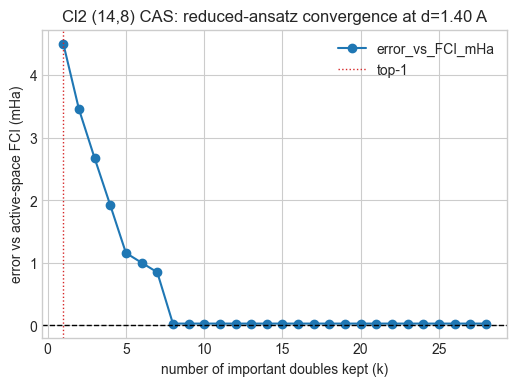

In [5]:
# Sanity check: confirm the top-k doubles truncation is genuinely reducing the ansatz.
# If the reduction were being bypassed, k=1 would already reproduce FCI.
# Instead the error should decrease smoothly as k grows, saturating once the
# important doubles are included. NOTE: this (14,8) CAS has only 1 active virtual
# orbital (no=7, nv=1) -> only 28 doubles total, so ~5 of them already recover FCI.

conv_d = 1.4
conv_mol = make_cl2(conv_d)

conv_ref = UCCSD(
    conv_mol,
    active_space=active_space,
    init_method="mp2",
    pick_ex2=True,
    sort_ex2=True,
    run_fci=True,
)
e_full_conv = conv_ref.kernel()
e_fci_conv = conv_ref.e_fci

# total number of available double parameters in this active space
probe_conv = UCCSD(
    conv_mol, active_space=active_space, init_method="mp2",
    pick_ex2=False, sort_ex2=False, run_fci=False,
)
_pid_ops = {}
for op, pid in zip(probe_conv.ex_ops, probe_conv.param_ids):
    _pid_ops.setdefault(pid, []).append(op)
n_doubles_total = sum(1 for ops in _pid_ops.values() if all(len(o) == 4 for o in ops))

conv_rows = []
for k in range(1, n_doubles_total + 1):
    red_k, _, ex_ops_k, _ = build_reduced_topk_doubles_ucc(conv_mol, active_space, k)
    e_k = red_k.kernel()
    conv_rows.append({
        "n_doubles_kept": k,
        "n_ex_ops": len(ex_ops_k),
        "E_reduced_Ha": e_k,
        "error_vs_FCI_mHa": (e_k - e_fci_conv) * 1000,
    })

conv_df = pd.DataFrame(conv_rows)
print(f"Convergence demo at d = {conv_d:.2f} A  (no=7, nv=1, total doubles={n_doubles_total})")
print(f"HF  = {conv_ref.e_hf:.8f} Ha")
print(f"FCI = {e_fci_conv:.8f} Ha   full UCCSD = {e_full_conv:.8f} Ha")
display(conv_df)

ax = conv_df.plot(
    x="n_doubles_kept",
    y="error_vs_FCI_mHa",
    marker="o",
    legend=False,
    figsize=(6, 4),
)
ax.axhline(0.0, color="black", linestyle="--", linewidth=1.0)
ax.axvline(top_k, color="tab:red", linestyle=":", linewidth=1.0, label=f"top-{top_k}")
ax.set_xlabel("number of important doubles kept (k)")
ax.set_ylabel("error vs active-space FCI (mHa)")
ax.set_title(f"Cl2 (14,8) CAS: reduced-ansatz convergence at d={conv_d:.2f} A")
ax.legend()
plt.show()

,d_angstrom,E_no_active_space_Ha,E_active_space_Ha,E_topk_doubles_Ha,active_minus_no_active_mHa,topk_minus_active_mHa,topk_minus_fci_active_mHa,n_ex_ops_kept,selected_param_ids
0,1.0,-904.942345,-904.942283,-904.939808,0.061935,2.475316,2.475316,1,[21]
1,1.2,-907.291315,-907.291211,-907.287484,0.103773,3.727272,3.727272,1,[21]
2,1.4,-908.390255,-908.390095,-908.385593,0.159874,4.502209,4.502209,1,[21]
3,1.6,-908.877875,-908.877713,-908.872541,0.162456,5.171529,5.171529,1,[21]
4,1.8,-909.076456,-909.076320,-909.070705,0.136015,5.615195,5.615195,1,[21]
5,2.0,-909.141156,-909.141050,-909.135385,0.105492,5.665021,5.665021,1,[12]
6,2.2,-909.147348,-909.147269,-909.141967,0.078649,5.301806,5.301806,1,[21]
7,2.4,-909.132506,-909.132450,-909.127827,0.056230,4.623030,4.623030,1,[21]
8,2.6,-909.114687,-909.114648,-909.110879,0.038259,3.769456,3.769456,1,[34]
9,2.8,-909.100962,-909.100936,-909.098035,0.025215,2.901185,2.901185,1,[34]


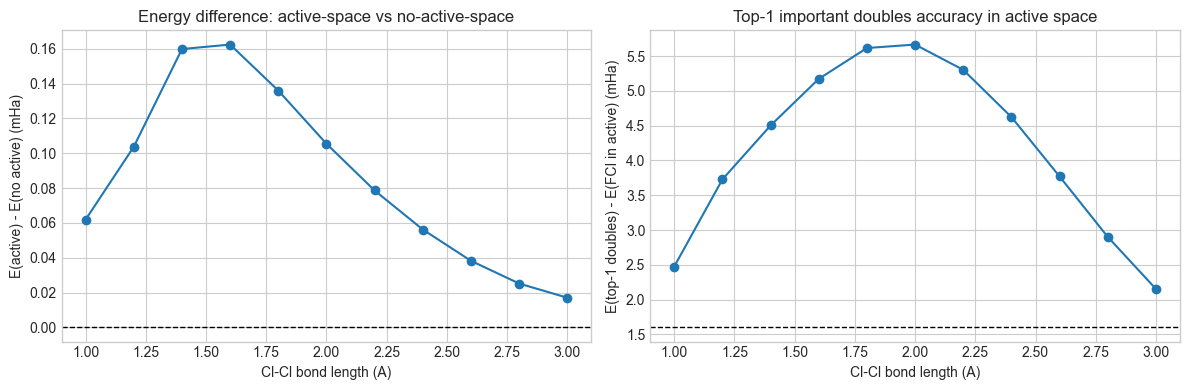

In [6]:
display(scan_df)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

scan_df.plot(
    x="d_angstrom",
    y="active_minus_no_active_mHa",
    marker="o",
    legend=False,
    ax=axes[0],
)
axes[0].axhline(0.0, color="black", linestyle="--", linewidth=1.0)
axes[0].set_xlabel("Cl-Cl bond length (A)")
axes[0].set_ylabel("E(active) - E(no active) (mHa)")
axes[0].set_title("Energy difference: active-space vs no-active-space")

scan_df.plot(
    x="d_angstrom",
    y="topk_minus_fci_active_mHa",
    marker="o",
    legend=False,
    ax=axes[1],
)
axes[1].axhline(1.6, color="black", linestyle="--", linewidth=1.0)
axes[1].set_xlabel("Cl-Cl bond length (A)")
axes[1].set_ylabel(f"E(top-{top_k} doubles) - E(FCI in active) (mHa)")
axes[1].set_title(f"Top-{top_k} important doubles accuracy in active space")

plt.tight_layout()
plt.show()

## Notes

- Molecule is `Cl2` in STO-3G with linear geometry `M(atom=[["Cl",0,0,-d/2],["Cl",0,0,d/2]])`.
- Paper / active-space encoding ([arXiv:2212.08006](https://arxiv.org/abs/2212.08006), Sec. II.1):
  - frozen core (26 electrons);
  - **8 active spatial orbitals**;
  - **14 active electrons** in CAS → `active_space=(14, 8)` → **16 qubits**.
- `configure_ucc_initial_state(ucc, use_multireference=False)` is the default and keeps TenCirChem RHF HF.
- `configure_ucc_initial_state(ucc, use_multireference=True)` builds paper Eq. (6):
  `(|HF⟩ − β|exc⟩)/√(1+β²)` with a HOMO→LUMO double excitation in both spin sectors; β is optimized by minimizing `⟨Ψ_ref|H|Ψ_ref⟩`.
- `E_no_active_space_Ha` is full STO-3G UCCSD (no CAS truncation).
- `E_active_space_Ha` is UCCSD in the requested active space.
- Top-`k` selection (`top_k` variable) is constrained to **double excitations only**, ranked by `|MP2 initial theta|`.
- Bond-length scan: `d = 1.0 ... 3.0 A` in steps of `0.2 A`.

### Why top-k doubles can be almost exact in this CAS

- `active_space=(14, 8)` has `no = 7` occupied and only `nv = 1` virtual active spatial orbital.
- The full doubles pool is only **28 parameters**; ~5 dominate.
- The convergence cell sweeps `k = 1 .. 28` and shows error decreasing smoothly (not a bypass bug).
- For a stronger truncation test, enlarge the virtual space (e.g. freeze fewer cores) or use a larger basis.

In [7]:
# # UCCSD parameter / operator counting for closed-shell systems
# #
# # These formulas reproduce *exactly* how TenCirChem's spin-adapted UCCSD builds its
# # excitation operators (tencirchem/static/ucc.py :: get_ex1_ops / get_ex2_ops).
# # A "parameter" is one unique amplitude; an "ex_op" is one spin-orbital excitation
# # operator. One parameter maps to 1, 2, or 4 ex_ops depending on its spin structure.

# from math import comb


# def count_uccsd(n_electrons: int, n_spatial_orbitals: int):
#     """
#     Count UCCSD unique parameters and excitation operators for a closed-shell system,
#     matching TenCirChem's construction exactly.

#     Parameters
#     ----------
#     n_electrons : int
#         Total number of (active) electrons (must be even for closed-shell).
#     n_spatial_orbitals : int
#         Number of spatial orbitals in the active space.

#     Returns
#     -------
#     dict with parameter and ex_op counts for singles and doubles.

#     Construction (let o = n_o occupied spatial, v = n_v virtual spatial)
#     --------------------------------------------------------------------
#     SINGLES  -- loop i in [0,o), a in [0,v); each generates an αα and a ββ operator
#                 that share one amplitude:
#         single_params = o * v
#         single_ex_ops = 2 * o * v

#     DOUBLES  -- two contributions, mirroring get_ex2_ops:

#       (1) Same-spin (αα and ββ): i<j and a<b. One amplitude -> 2 ops (αα, ββ):
#             params = C(o,2) * C(v,2)
#             ex_ops = 2 * C(o,2) * C(v,2)

#       (2) Opposite-spin (one α + one β): loop j<=i, b<=a with three sub-cases:
#           - paired (i==j and a==b): 1 op per amplitude
#                 params = o * v,           ex_ops = o * v
#           - one index pair equal (i==j XOR a==b): 2 ops per amplitude (reflection)
#                 params = o*C(v,2) + C(o,2)*v
#                 ex_ops = 2 * (o*C(v,2) + C(o,2)*v)
#           - both pairs distinct (i>j and a>b): reflection + exchange -> 2 amplitudes,
#             4 ops total:
#                 params = 2 * C(o,2) * C(v,2)
#                 ex_ops = 4 * C(o,2) * C(v,2)

#       Totals:
#         double_params = 3*C(o,2)*C(v,2) + o*C(v,2) + C(o,2)*v + o*v
#         double_ex_ops = 6*C(o,2)*C(v,2) + 2*o*C(v,2) + 2*C(o,2)*v + o*v
#     """
#     if n_electrons % 2 != 0:
#         raise ValueError("Closed-shell only: n_electrons must be even")

#     n_o = n_electrons // 2
#     n_v = n_spatial_orbitals - n_o

#     if n_o < 0 or n_v < 0:
#         raise ValueError("Invalid: n_spatial_orbitals must be >= n_electrons/2")

#     co2 = comb(n_o, 2)
#     cv2 = comb(n_v, 2)

#     # Singles
#     single_params = n_o * n_v
#     single_ex_ops = 2 * single_params

#     # Doubles: same-spin (αα/ββ)
#     double_same_params = co2 * cv2
#     double_same_ex_ops = 2 * co2 * cv2

#     # Doubles: opposite-spin (mixed α/β), split by sub-case
#     double_opp_paired_params = n_o * n_v
#     double_opp_paired_ex_ops = n_o * n_v

#     double_opp_reflect_params = n_o * cv2 + co2 * n_v
#     double_opp_reflect_ex_ops = 2 * (n_o * cv2 + co2 * n_v)

#     double_opp_exchange_params = 2 * co2 * cv2
#     double_opp_exchange_ex_ops = 4 * co2 * cv2

#     double_opp_params = (
#         double_opp_paired_params + double_opp_reflect_params + double_opp_exchange_params
#     )
#     double_opp_ex_ops = (
#         double_opp_paired_ex_ops + double_opp_reflect_ex_ops + double_opp_exchange_ex_ops
#     )

#     double_params = double_same_params + double_opp_params
#     double_ex_ops = double_same_ex_ops + double_opp_ex_ops

#     return {
#         "n_spatial": n_spatial_orbitals,
#         "n_electrons": n_electrons,
#         "n_occ_spatial": n_o,
#         "n_vir_spatial": n_v,
#         "single_params": single_params,
#         "single_ex_ops": single_ex_ops,
#         "double_params_same_spin": double_same_params,
#         "double_params_opp_spin": double_opp_params,
#         "double_params_total": double_params,
#         "double_ex_ops_same_spin": double_same_ex_ops,
#         "double_ex_ops_opp_spin": double_opp_ex_ops,
#         "double_ex_ops_total": double_ex_ops,
#         "total_params": single_params + double_params,
#         "total_ex_ops": single_ex_ops + double_ex_ops,
#     }


# # Demo: show counts for the (14, 8) active space used in this notebook
# demo_counts = count_uccsd(14, 8)
# demo_df = pd.DataFrame([demo_counts])
# print("UCCSD counting for Cl2 active space (10 electrons, 6 spatial orbitals):")
# print(f"  Occupied spatial: {demo_counts['n_occ_spatial']}, Virtual spatial: {demo_counts['n_vir_spatial']}")
# print(f"  Singles: {demo_counts['single_params']} params, {demo_counts['single_ex_ops']} ex_ops")
# print(f"  Doubles same-spin (αα/ββ): {demo_counts['double_params_same_spin']} params, {demo_counts['double_ex_ops_same_spin']} ex_ops")
# print(f"  Doubles opp-spin  (α/β):   {demo_counts['double_params_opp_spin']} params, {demo_counts['double_ex_ops_opp_spin']} ex_ops")
# print(f"  Doubles total: {demo_counts['double_params_total']} params, {demo_counts['double_ex_ops_total']} ex_ops")
# print(f"  TOTAL: {demo_counts['total_params']} unique parameters, {demo_counts['total_ex_ops']} ex_ops")
# display(demo_df)

# # Interactive: just change these numbers and run the cell again
# your_n_electrons = 10   # <-- change me (must be even)
# your_n_spatial = 6      # <-- change me

# your_counts = count_uccsd(your_n_electrons, your_n_spatial)
# your_df = pd.DataFrame([your_counts])
# print(f"\nYour input (n_elec={your_n_electrons}, n_spatial={your_n_spatial}):")
# print(f"  Single parameters: {your_counts['single_params']}")
# print(f"  Double parameters: {your_counts['double_params_total']}")
# print(f"  Total parameters:  {your_counts['total_params']}  |  Total ex_ops: {your_counts['total_ex_ops']}")
# display(your_df)

# print("""
# Scaling notes:
# - Singles scale as O(n_o * n_v) ~ O(N^2) where N is system size
# - Doubles scale as O(n_o^2 * n_v^2) ~ O(N^4)
# - For large active spaces, doubles dominate the parameter count
# - This is why picking only top-k important doubles (by MP2 amplitude) is crucial for NISQ!
# """)

In [8]:
# # Cross-check count_uccsd() formulas against full TenCirChem UCCSD ansätze.
# from tencirchem.molecule import h2, h4, lih


# def count_uccsd_from_tencirchem(mol, active_space=None):
#     """Measure singles/doubles from an unscreened UCCSD instance."""
#     ucc = UCCSD(
#         mol,
#         active_space=active_space,
#         init_method="mp2",
#         pick_ex2=False,
#         sort_ex2=False,
#         run_fci=False,
#         run_ccsd=False,
#     )

#     pid_to_ops = {}
#     for op, pid in zip(ucc.ex_ops, ucc.param_ids):
#         pid_to_ops.setdefault(pid, []).append(op)

#     single_pids = [pid for pid, ops in pid_to_ops.items() if all(len(o) == 2 for o in ops)]
#     double_pids = [pid for pid, ops in pid_to_ops.items() if all(len(o) == 4 for o in ops)]

#     no, nv = ucc.no, ucc.nv
#     return {
#         "n_electrons": 2 * no,
#         "n_spatial_orbitals": no + nv,
#         "single_params": len(single_pids),
#         "single_ex_ops": sum(len(pid_to_ops[p]) for p in single_pids),
#         "double_params": len(double_pids),
#         "double_ex_ops": sum(len(pid_to_ops[p]) for p in double_pids),
#         "total_params": ucc.n_params,
#         "total_ex_ops": len(ucc.ex_ops),
#     }


# def compare_uccsd_counts(label, mol, active_space=None):
#     """Return one row comparing analytic vs TenCirChem counts."""
#     tc = count_uccsd_from_tencirchem(mol, active_space=active_space)
#     formula = count_uccsd(tc["n_electrons"], tc["n_spatial_orbitals"])

#     row = {
#         "molecule": label,
#         "active_space": str(active_space),
#         "n_electrons": tc["n_electrons"],
#         "n_spatial": tc["n_spatial_orbitals"],
#         # singles
#         "single_params_formula": formula["single_params"],
#         "single_params_tencirchem": tc["single_params"],
#         "single_ex_ops_formula": formula["single_ex_ops"],
#         "single_ex_ops_tencirchem": tc["single_ex_ops"],
#         # doubles (params)
#         "double_params_formula": formula["double_params_total"],
#         "double_params_tencirchem": tc["double_params"],
#         "double_same_spin_formula": formula["double_params_same_spin"],
#         "double_opp_spin_formula": formula["double_params_opp_spin"],
#         # doubles (ex_ops): now exact, not an estimate
#         "double_ex_ops_formula": formula["double_ex_ops_total"],
#         "double_ex_ops_tencirchem": tc["double_ex_ops"],
#         # totals
#         "total_params_formula": formula["total_params"],
#         "total_params_tencirchem": tc["total_params"],
#         "total_ex_ops_formula": formula["total_ex_ops"],
#         "total_ex_ops_tencirchem": tc["total_ex_ops"],
#     }

#     row["single_params_match"] = row["single_params_formula"] == row["single_params_tencirchem"]
#     row["single_ex_ops_match"] = row["single_ex_ops_formula"] == row["single_ex_ops_tencirchem"]
#     row["double_params_match"] = row["double_params_formula"] == row["double_params_tencirchem"]
#     row["double_ex_ops_match"] = row["double_ex_ops_formula"] == row["double_ex_ops_tencirchem"]
#     row["total_params_match"] = row["total_params_formula"] == row["total_params_tencirchem"]
#     row["total_ex_ops_match"] = row["total_ex_ops_formula"] == row["total_ex_ops_tencirchem"]

#     return row


# TEST_MOLECULES = [
#     ("H2 (full)", h2, None),
#     ("H4 d=1.0 (full)", h4(1.0), None),
#     ("LiH d=1.6 (full)", lih(), None),
#     ("H2O (full, STO-3G)", M(atom="O 0 0 0; H 0 0 0.96; H 0 0.92 0.24", basis="sto-3g"), None),
#     ("Cl2 d=1.4 CAS (14,8)", make_cl2(1.4), active_space),
# ]

# validation_rows = [compare_uccsd_counts(label, mol, cas) for label, mol, cas in TEST_MOLECULES]
# validation_df = pd.DataFrame(validation_rows)

# MATCH_COLS = [
#     "single_params_match",
#     "single_ex_ops_match",
#     "double_params_match",
#     "double_ex_ops_match",
#     "total_params_match",
#     "total_ex_ops_match",
# ]

# print("UCCSD singles/doubles: analytic formulas vs TenCirChem (pick_ex2=False, full ansatz)")
# display(
#     validation_df[
#         [
#             "molecule",
#             "n_electrons",
#             "n_spatial",
#             "single_params_formula",
#             "single_params_tencirchem",
#             "single_ex_ops_formula",
#             "single_ex_ops_tencirchem",
#             "double_params_formula",
#             "double_params_tencirchem",
#             "double_ex_ops_formula",
#             "double_ex_ops_tencirchem",
#             "total_params_formula",
#             "total_params_tencirchem",
#             "total_ex_ops_formula",
#             "total_ex_ops_tencirchem",
#         ]
#         + MATCH_COLS
#     ]
# )

# all_checks = validation_df[MATCH_COLS].all().all()

# if all_checks:
#     print("\nAll parameter AND ex_ops counts match TenCirChem UCCSD exactly.")
# else:
#     mismatch_mask = ~validation_df[MATCH_COLS].all(axis=1)
#     mismatches = validation_df.loc[
#         mismatch_mask,
#         [
#             "molecule",
#             "total_params_formula",
#             "total_params_tencirchem",
#             "total_ex_ops_formula",
#             "total_ex_ops_tencirchem",
#         ],
#     ]
#     print("\nMISMATCH detected:")
#     display(mismatches)